# SIDNE 1 Model 2035-2050 
(Spain Industry Decarbonisation with Nuclear Energy) 

This first module focuses in the Chemical Industry decarbonization with SMR-CHP 
(Economic analysis using PyPSA opensource toolbox)

Hypothesis: 
- Demand data from MECs (3% scaled down to spain case;  check calculus [file](https://docs.google.com/spreadsheets/d/1pLw4c-ZX__JsrjUIHaK1mmeCst81JXG1elViPpqSP6U/edit?gid=889823888#gid=889823888))
- Interest Rate Nominal conservative = 8% ([NREL](https://atb.nrel.gov/electricity/2024/data) ATB data)
- SMR costs from [NREL](https://atb.nrel.gov/electricity/2024/data). 
- GAS-CHP costs from PyPSA or [NREL](https://atb.nrel.gov/electricity/2024/data). 


The code is based in: 
- [basic example](https://pypsa.readthedocs.io/en/latest/examples/chp-fixed-heat-power-ratio.html), [Biomass example](https://pypsa.readthedocs.io/en/latest/examples/biomass-synthetic-fuels-carbon-management.html), and [variable heat-power example](https://pypsa.readthedocs.io/en/latest/examples/power-to-gas-boiler-chp.html)
- Previous work developed by Antonio Vaya and Daniel Juiz

In [1458]:
import numpy as np
import numpy_financial as npf
import matplotlib.pyplot as plt
import pandas as pd
import pypsa
import packages
# conda install openpyxl
# plt.style.use("bmh")
from IPython.display import display, HTML


## Introduction
1. Units_from_Costs_final2024.xml input (2023)
  - Investment (Overnight capital cost): USD/kWe*--> (Will be annualized to be used in SIDNE PyPSA Model)
  - FOM: USD/kW/year
  - VOM: USD/MWh
  - Fuel: USD/MWh
  - Lifetime: years
  - carbon_intensity: gCO2/kWh
  - Capacity: MW (Net Capacity Factor: NREL)
  - Constrution time: years
  - load_factor: Unitarized
  - Tax: Unitarized
  - Rate: Unitarized 
  - Carbon_cost: USD/ton CO2 (in is not used in PyPSA)

In [1459]:
#This line comented can be used to updated the costs from a cost_final24.xlsx Excel file

# cost=pd.read_excel('./cost_final24.xlsx') #read from an excel file which is converted to csv
# csv_file11 = "./cost_final24.csv" # Specify the output CSV file path
# cost.to_csv(csv_file11, index=False) #Save the DataFrame as a CSV file

#Costs updated, cost.final24.csv in directory, saved in the cost Data Frame
cost=pd.read_csv('./cost_final24.csv', index_col=0)

#Sensibility parameters
select_rate=cost.loc["SMR_CHP","rate"] 

In [1460]:
# Compute all LCOEs
df = pd.DataFrame()
techs=['SMR_CHP', 'Gas_CHP']

for tech in techs:
    df=pd.concat([df, packages.LCOE(tech, cost, tech)])
# df

### 1.1 Carbon costs, intensity & taxes
Add: 
- Carbon costs, from the 2024 World Energy Outlook [website](https://www.iea.org/reports/world-energy-outlook-2024). 
- Carbon intensity values to compute CO2 emissions
- Taxes to nuclear energy: taken from PWC'[report](https://www.pwc.es/es/publicaciones/energia/assets/fiscalidad-parque-nuclear.pdf).

In [1461]:
#Carbon costs updated to 90 USD/tonCO2 by 2024 World Energy Outlook.
cost.loc["Gas_CHP", "carbon_cost"]=90.  # USD/tonCO2
cost["tax"] = cost["tax"].astype(float)

#Adding carbon intensity in tCO2/MWh_th (from gCO2/kWh)
cost["carbon_intensity"] = cost["carbon_intensity"].astype(float)
cost.loc["Gas_CHP", "carbon_intensity"]=cost.loc["Gas_CHP", "carbon_intensity"]*0.5/1000
# cost

#impact of taxes, 16.31 // Source PWC 
cost.loc["SMR_CHP", "tax"]=16.31

Annualize investment values

In [1462]:
#annualiaze investment costs
lifetime= cost["lifetime"].values

annualized_inv=[packages.annualized(val, select_rate, lifetime[i])*1000 for i, val 
in enumerate(cost["investment"].values)] #1000_factor_to_convert_to_USD/MW/year

cost["annualized_investment"]=annualized_inv #Add to cost dataframe

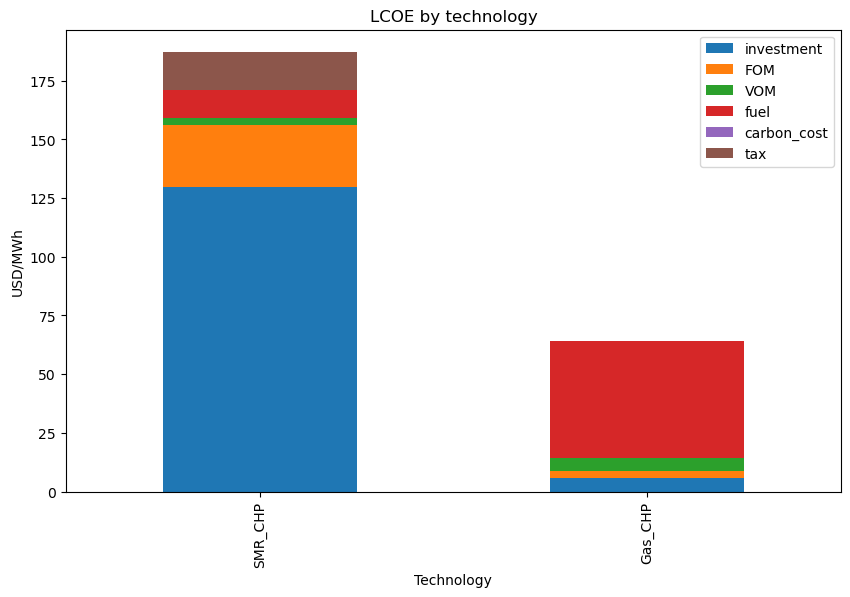

In [1463]:
#Plot LCOE
df3 = pd.DataFrame()
for tech in techs:
    df3=pd.concat([df3, packages.LCOE(tech, cost, tech)])

df3['Total'] = df3.sum(axis=1)
df3 = df3.sort_values(by='Total', ascending=False)
df3 = df3.drop(columns=['Total'])

df3.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.xlabel('Technology')
plt.ylabel('USD/MWh')
plt.title('LCOE by technology')
plt.show()

Units of cost_dataframe for PyPSA model

  - Investment (Overnight capital cost): USD/kWe
  - FOM: USD/kW/year
  - VOM: USD/MWh
  - Fuel: USD/MWh
  - Lifetime: years
  - carbon_intensity: gCO2/kWh
  - Capacity: MW (Net Capacity Factor: NREL)
  - Constrution time: years
  - load_factor: Unitarized
  - Tax: Unitarized
  - Rate: Unitarized
  - Carbon_cost: USD/ton CO2
  - annualized_investment: USD/MWe/year

### 1.1 Electric prices and tech comparison

First upload 2023 historical data: profiles, loads and prices
(Source:  [ENTSOE Transparency Platform](https://newtransparency.entsoe.eu/generation/installed/perType?appState=%7B%22sa%22%3A%5B%22BZN%7C10YES-REE------0%22%5D%2C%22st%22%3A%22BZN%22%2C%22mm%22%3Atrue%2C%22ma%22%3Afalse%2C%22sp%22%3A%22HALF%22%2C%22dt%22%3A%22TABLE%22%2C%22df%22%3A%5B%222024%22%2C%222024%22%5D%2C%22tz%22%3A%22CET%22%7D))

![Alt text](ElectricityPrices23.png)

In [1464]:
CO2_reduction=0.5 # 50% CO2 emissions reduction for scenario 2035
# Using a carbon cost of: 90 USD/tonCO2 by 2024 World Energy Outlook --> cost.loc["Gas_CHP", "carbon_cost"]=90.
extra_cost=10000

# Filtrar un rango de tiempo específico (para comprobar hipótesis)------
start_time = "2023-01-02 01:00:00"                                         
end_time = "2023-01-02 10:00:00"                                        
# end_time = "2023-12-31 23:00:00"              # All 8760 hours of simulation 
snapshots=pd.date_range(start_time, end_time, freq="h")
#----------------------------------------------------------------------------------------
#----------------------------------------------------------------------------------------
# Cargar el archivo ES_Price.csv e indexarlo con una serie temporal
price_data = pd.read_csv('./ES_Price.csv')
price_data.index = pd.date_range(start="2023-01-01 00:00:00", periods=8760, freq="h")
filtered_prices = price_data.loc[start_time:end_time]
# print(filtered_prices) # Verifica que los datos filtrados sean correctos
PriceES = pd.read_csv('./ES_Price.csv').iloc[:len(snapshots)]
assert len(PriceES) == len(snapshots), "El número de filas en PriceES no coincide con los snapshots"

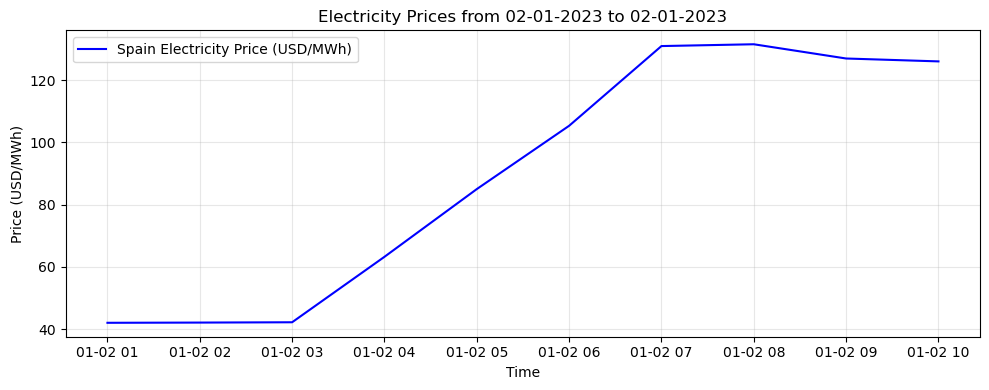

In [1465]:
# Graficar los precios en el rango de tiempo
plt.figure(figsize=(10, 4))
plt.plot(snapshots, filtered_prices["Price"], label="Spain Electricity Price (USD/MWh)", color="blue")
plt.xlabel("Time")
plt.ylabel("Price (USD/MWh)")
# Ajustar el título para mostrar solo día, mes y año
start_date = pd.to_datetime(start_time).strftime("%d-%m-%Y")
end_date = pd.to_datetime(end_time).strftime("%d-%m-%Y")
plt.title(f"Electricity Prices from {start_date} to {end_date}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

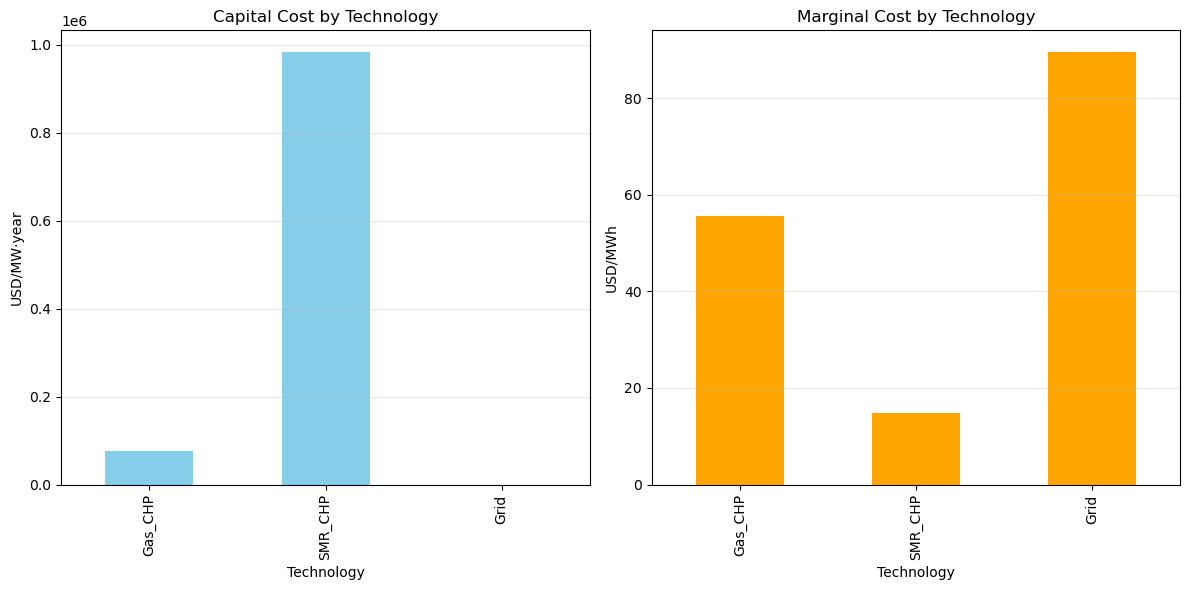

,Technology,Capital Cost (USD/MW·year),Marginal Cost (USD/MWh)
0,Gas_CHP,75256.906429,55.500
1,SMR_CHP,983580.513255,14.800
2,Grid,0.000000,89.547


In [1466]:
# Define the data
data = {
    "Technology": ["Gas_CHP", "SMR_CHP", "Grid"],
    "Capital Cost (USD/MW·year)": [
        cost.loc["Gas_CHP", "annualized_investment"] + cost.loc["Gas_CHP", "FOM"] * 1000,
        cost.loc["SMR_CHP", "annualized_investment"] + cost.loc["SMR_CHP", "FOM"] * 1000,
        0  # Grid has no capital cost
    ],
    "Marginal Cost (USD/MWh)": [
        cost.loc["Gas_CHP", "VOM"] + cost.loc["Gas_CHP", "fuel"],
        cost.loc["SMR_CHP", "VOM"] + cost.loc["SMR_CHP", "fuel"],
        filtered_prices["Price"].mean()  # Average price for the grid
    ]
}

# Create a DataFrame
costs_df = pd.DataFrame(data)

# Plot the data as a bar chart
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Capital Cost Bar Chart
costs_df.plot(
    x="Technology",
    y="Capital Cost (USD/MW·year)",
    kind="bar",
    ax=ax[0],
    color="skyblue",
    legend=False
    )
ax[0].set_title("Capital Cost by Technology")
ax[0].set_ylabel("USD/MW·year")
ax[0].set_xlabel("Technology")
ax[0].grid(axis="y", alpha=0.3)

# Marginal Cost Bar Chart
costs_df.plot(
    x="Technology",
    y="Marginal Cost (USD/MWh)",
    kind="bar",
    ax=ax[1],
    color="orange",
    legend=False
    )
ax[1].set_title("Marginal Cost by Technology")
ax[1].set_ylabel("USD/MWh")
ax[1].set_xlabel("Technology")
ax[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Display the table with a title
display(HTML("<h3>Cost Comparison Table</h3>"))
display(costs_df)


## 2. Network & CO2 constraint

In [1467]:
network=pypsa.Network() # Creates empty PyPSA network object called network
#Each hour is going to be a snapshot to optimize (Historical data loaded, as ES prices, have 8760 inputs)
network.set_snapshots(snapshots) # set the time range with hourly frequency

# 0) define carriers (optional) and co2 traceability
network.add("Carrier", "Gas",
            co2_emissions=cost.loc["CCGT","carbon_intensity"]) 
network.add("Carrier", "nuclear")
network.add("Carrier", "heat")
network.add("Carrier","electricity")

#---------------------------------------------------------------------------------------------------------------
# 0.1) Define emissions constraint------------------------------------------------------------------------------
CO2_avoided=cost.loc["Gas_CHP", "carbon_intensity"]*2.92E+06 # 2.92E+06 fuel avoided in MWh/year (maximum avoided [MECS 2018] considering fuel as 100% natural gas) 
limit_CO2=CO2_avoided*CO2_reduction # 50% reduction of CO2 emissions in tCO2/year
network.add("GlobalConstraint", "co2_limit", sense="<=", constant=limit_CO2)
#---------------------------------------------------------------------------------------------------------------
# 0.2) Define the CO2 price for the optimization problem--------------------------------------------------------


# 1) Main Buses & loads----------------------------------------------------------------
network.add("Bus", "Industry Electricity", carrier="electricity") 
network.add("Load", "Industry Electricity Load", bus="Industry Electricity", p_set=135)

network.add("Bus", "Industry Heat", carrier="heat")
network.add("Load", "Industry Heat Load", bus="Industry Heat", p_set=294) # 294

# 2)  Fuel buses ----------------------------------------------------------------------
network.add("Bus", "uranium_UO2", carrier="nuclear")                  
network.add("Bus", "Gas_Fuel_in", carrier="Gas")
network.add("Bus", "Spain_grid", carrier="electricity")

Index(['Spain_grid'], dtype='object')

### 2.1 Stores & DUMP components

In [1468]:
# STORES ------------------------------------------------------------------------------
network.add("Store", "Spain gas", bus="Gas_Fuel_in",
    e_initial=1e10, 
    # e_nom=0,    # set pre-existing e_nom=50?
    # e_cyclic=True,
    e_nom_extendable=True)
network.add("Store", "uranium", bus="uranium_UO2",
    e_initial=1e10, 
    # e_nom=0, # set pre-existing e_nom=0?
    # e_cyclic=True,
    e_nom_extendable=True)
network.add("Store", "Spain grid", bus="Spain_grid",
    e_initial=1e15, 
    # e_nom=100, # set pre-existing e_nom=0?
    # e_cyclic=True,
    e_nom_extendable=True)
#---------------------------------------------------------------------------------------
# DUMP components with one-directional link (+bus+store)--------------------------------
network.add("Bus", "Heat Dump", carrier="heat")
network.add("Link", "Heat_Dump_Link",
    bus0="Industry Heat",
    bus1="Heat Dump",
    p_nom=1e10,
    # p_nom_extendable=True,
    capital_cost=10, # 400 USD/MW·year
    marginal_cost=5, # 40 USD/MWh
    efficiency=1)
network.add("Store", "Heat_Dump_Store", bus="Heat Dump",
    e_initial=0, 
    e_nom=5e100) # set large e_nom

network.add("Bus", "Electricity Dump", carrier="electricity") 
network.add( "Link", "Electricity_Dump_Link",
    bus0="Industry Electricity",
    bus1="Electricity Dump",
    p_nom=1e10,
    # p_nom_extendable=True,
    capital_cost=10, # 400 USD/MW·year
    marginal_cost=5, # 80 USD/MWh
    efficiency=1)
network.add("Store", "Electricity_Dump_Store", bus="Electricity Dump",
    e_initial=0, 
    e_nom=1e15) # set large e_nom
#----------------------------------------------------------------------------------------


Index(['Electricity_Dump_Store'], dtype='object')

In [1469]:
# LINKS----------------------------------------------------------------------------------
network.add( "Link", "Link_Gas_CHP",               
    bus0="Gas_Fuel_in",
    bus1="Industry Electricity",
    bus2="Industry Heat",
    carrier="Gas",
    p_nom_min=0,  # Optional: Minimum capacity
    p_nom_max=100, # maximum capacity of 1000 MW
    p_nom_extendable=True, # Optimizes de p_nom value
    capital_cost=cost.loc["Gas_CHP","annualized_investment"]+cost.loc["Gas_CHP","FOM"]*1000,     # fixed period costs of extending p_nom by 1 MW
    marginal_cost=(cost.loc["Gas_CHP","VOM"]+cost.loc["Gas_CHP","fuel"]), 
    efficiency=0.4, 
    efficiency2=0.35,
)

network.add( "Link", "Link_Gas_conventional",               
    bus0="Gas_Fuel_in",
    bus1="Industry Electricity",
    bus2="Industry Heat",
    carrier="Gas",
    p_nom_min=0,  # Optional: Minimum capacity
    p_nom_max=1000, # maximum capacity of 1000 MW
    p_nom_extendable=True, # Optimizes de p_nom value
    capital_cost=cost.loc["Gas_CHP","annualized_investment"]+cost.loc["Gas_CHP","FOM"]*1000,     # fixed period costs of extending p_nom by 1 MW
    marginal_cost=(cost.loc["Gas_CHP","VOM"]+cost.loc["Gas_CHP","fuel"]), 
    efficiency=0,
    efficiency2=0.35,
)

network.add( "Link", "Link_SMR_CHP",
    bus0="uranium_UO2",
    bus1="Industry Electricity",
    bus2="Industry Heat", 
    carrier="nuclear",
    p_nom_min=0,  # Optional: Minimum capacity
    p_nom_max= 1000, # maximum capacity of 1000 MW
    p_nom_extendable=True, # Optimizes de p_nom value
    capital_cost=cost.loc["SMR_CHP","annualized_investment"]+cost.loc["SMR_CHP","FOM"]*1000, #annualized USD/MWe
    marginal_cost=(cost.loc["SMR_CHP","VOM"]+cost.loc["SMR_CHP","fuel"]),
    efficiency=0.45, 
    efficiency2=0.35,
)
network.add("Link", "Link_Spain_Grid",
    bus0="Spain_grid",
    bus1="Industry Electricity",
    bus2="Industry Heat",
    carrier="electricity",
    p_nom=1000, 
    capital_cost=0, # USD/MW·year (no capital cost for grid)
    marginal_cost=5, # Spain energy prices for 2023
    efficiency=1,      # electricity transport
    efficiency2=0, # no heat generation
    )
#add electricity to heat link & short-time heat store
# network.add("Link","Heat_pump",
#     bus0="Industry Electricity",
#     bus1="Industry Heat",
#     capital_cost=4e7, # USD/MW·year
#     marginal_cost=50, # USD/MWh
#     p_nom_extendable=True,
#     efficiency=0.9,
# )
# network.add("Store", "water tank", bus="Industry Heat", 
#             e_initial=1000,
#             e_cyclic=True, 
#             e_nom_extendable=True)
network.optimize()

INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.2s
INFO:linopy.io: Writing time: 0.2s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 166 primals, 350 duals
Objective: 7.60e+08
Solver model: available
Solver message: optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-fix-e-lower, Store-fix-e-upper, Store-ext-e-lower, Store-ext-e-upper, Store-energy_balance were not assigned to the network.
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 166 primals, 350 duals
Objective: 7.60e+08
Solver model: available
Solver message: optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-fix-e-lower, Store-fix-e-upper, Store-ext-e-lower, Store-ext-e-upper, S

('ok', 'optimal')

## 3. Plot Results

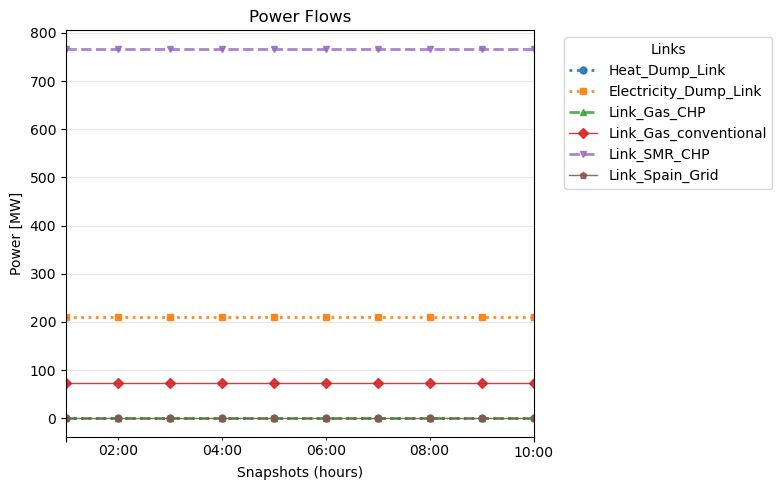

In [1470]:
# Plot all energy flows with different geometric markers for each line
markers = ['o', 's', '^', 'D', 'v', 'p', '*', 'h', 'x', '+']  # Define a list of markers
ax = network.links_t.p0.plot(
    figsize=(8, 5), 
    title="Power Flows", 
    style='-',  # Use lines by default
    alpha=0.9,  # Set transparency
    linewidth=1  # Adjust line width
)

# Assign a unique marker to each line and adjust marker size
for line, column, marker in zip(ax.lines, network.links_t.p0.columns, markers):
    line.set_marker(marker)
    line.set_markersize(line.get_linewidth() * 5)  # Set marker size proportional to line width

# Customize linestyle for CHP and Dump links
for line, column in zip(ax.lines, network.links_t.p0.columns):
    if "CHP" in column:  # Check if the link name contains "CHP"
        line.set_alpha(0.8)  # Increase transparency
        line.set_linewidth(2)  # Increase line width
        line.set_linestyle("--")  # Set linestyle to dashed
    if "Dump" in column:  # Check if the link name contains "Dump"
        line.set_alpha(0.9)  # Increase transparency
        line.set_linewidth(2)  # Increase line width
        line.set_linestyle(":")  # Set linestyle to dotted

plt.xlabel("Snapshots (hours)")  # Label for x-axis
plt.ylabel("Power [MW]")         # Label for y-axis
plt.legend(title="Links", bbox_to_anchor=(1.05, 1), loc='upper left')  # Add a legend
plt.tight_layout()               # Adjust layout to prevent overlapping
plt.grid(alpha=0.3)              # Add a grid for better readability
plt.show()

### 3.1 Power [MW] x 10 [h] = amount of energy [MWh]

In [1471]:
display(HTML("<h3>Fuel consumption (input) </h3>"))
display(network.links_t.p0) # fuel consumption (input)
display(HTML("<h3>Electricity Output</h3>"))
display(network.links_t.p1) # electricity output (negative values indicates it provides energy out)
display(HTML("<h3>Heat Output</h3>"))
display(network.links_t.p2) # heat output
print(network.objective)  # Verify cost objective value

Link,Heat_Dump_Link,Electricity_Dump_Link,Link_Gas_CHP,Link_Gas_conventional,Link_SMR_CHP,Link_Spain_Grid
snapshot,,,,,,
2023-01-02 01:00:00,-0.0,210.15,4.060244e-14,73.0,767.0,-0.0
2023-01-02 02:00:00,-0.0,210.15,4.060244e-14,73.0,767.0,-0.0
2023-01-02 03:00:00,-0.0,210.15,-0.000000e+00,73.0,767.0,-0.0
2023-01-02 04:00:00,-0.0,210.15,-0.000000e+00,73.0,767.0,-0.0
2023-01-02 05:00:00,-0.0,210.15,-0.000000e+00,73.0,767.0,-0.0
2023-01-02 06:00:00,-0.0,210.15,-0.000000e+00,73.0,767.0,-0.0
2023-01-02 07:00:00,-0.0,210.15,-0.000000e+00,73.0,767.0,-0.0
2023-01-02 08:00:00,-0.0,210.15,-0.000000e+00,73.0,767.0,-0.0
2023-01-02 09:00:00,-0.0,210.15,-0.000000e+00,73.0,767.0,-0.0


Link,Heat_Dump_Link,Electricity_Dump_Link,Link_Gas_CHP,Link_Gas_conventional,Link_SMR_CHP,Link_Spain_Grid
snapshot,,,,,,
2023-01-02 01:00:00,0.0,-210.15,-1.624098e-14,-0.0,-345.15,0.0
2023-01-02 02:00:00,0.0,-210.15,-1.624098e-14,-0.0,-345.15,0.0
2023-01-02 03:00:00,0.0,-210.15,0.000000e+00,-0.0,-345.15,0.0
2023-01-02 04:00:00,0.0,-210.15,0.000000e+00,-0.0,-345.15,0.0
2023-01-02 05:00:00,0.0,-210.15,0.000000e+00,-0.0,-345.15,0.0
2023-01-02 06:00:00,0.0,-210.15,0.000000e+00,-0.0,-345.15,0.0
2023-01-02 07:00:00,0.0,-210.15,0.000000e+00,-0.0,-345.15,0.0
2023-01-02 08:00:00,0.0,-210.15,0.000000e+00,-0.0,-345.15,0.0
2023-01-02 09:00:00,0.0,-210.15,0.000000e+00,-0.0,-345.15,0.0


Link,Heat_Dump_Link,Electricity_Dump_Link,Link_Gas_CHP,Link_Gas_conventional,Link_SMR_CHP,Link_Spain_Grid
snapshot,,,,,,
2023-01-02 01:00:00,0.0,0.0,-1.421085e-14,-25.55,-268.45,0.0
2023-01-02 02:00:00,0.0,0.0,-1.421085e-14,-25.55,-268.45,0.0
2023-01-02 03:00:00,0.0,0.0,0.000000e+00,-25.55,-268.45,0.0
2023-01-02 04:00:00,0.0,0.0,0.000000e+00,-25.55,-268.45,0.0
2023-01-02 05:00:00,0.0,0.0,0.000000e+00,-25.55,-268.45,0.0
2023-01-02 06:00:00,0.0,0.0,0.000000e+00,-25.55,-268.45,0.0
2023-01-02 07:00:00,0.0,0.0,0.000000e+00,-25.55,-268.45,0.0
2023-01-02 08:00:00,0.0,0.0,0.000000e+00,-25.55,-268.45,0.0
2023-01-02 09:00:00,0.0,0.0,0.000000e+00,-25.55,-268.45,0.0


760064546.3358728


In [1472]:
print("SMR Electricity Output:", network.links_t.p1["Link_SMR_CHP"].sum() )  # -MW
print("SMR Heat Output:", network.links_t.p2["Link_SMR_CHP"].sum())         # -MW
print("SMR Uranium Fuel Consumption:", network.links_t.p0["Link_SMR_CHP"].sum())    #+ MW

print("Gas_CHP Electricity Output:", network.links_t.p1["Link_Gas_CHP"].sum())
print("Gas_CHP Gas Consumption:", network.links_t.p0["Link_Gas_CHP"].sum())

print("Grid electricity output:", network.links_t.p1["Link_Spain_Grid"].sum())
print("Grid electricity Consumption:", network.links_t.p0["Link_Spain_Grid"].sum())

SMR Electricity Output: -3451.5000000000005
SMR Heat Output: -2684.4999999999995
SMR Uranium Fuel Consumption: 7670.0
Gas_CHP Electricity Output: -3.248195363474744e-14
Gas_CHP Gas Consumption: 8.12048840868686e-14
Grid electricity output: 0.0
Grid electricity Consumption: 0.0


Note that negative values for network.links_t.p1 indicate that the link is injecting power into bus1 (This aligns with PyPSA's [convention](https://pypsa.readthedocs.io/en/latest/user-guide/design.html#sign-conventions) where power injected into a bus is considered negative, while power withdrawn from a bus is positive). 

- network.links_t.p0 # energy flows through the input bus (bus0) in each link (for each snapshot) CONSUMO DE COMBUSTIBLE
- network.links_t.p1 # energy flows through the output bus1 (bus1) in each link (for each snapshot) ENERGY GENERATION (CONVERSION)
- network.links_t.p2 # energy flows through the output bus2 (bus2) in each link (for each snapshot) ENERGY GENERATION (CONVERSION)

In [1473]:
# check Gas, SMR & Grid tech costs in PyPSA

Marginal_Gas_cost=cost.loc["Gas_CHP","VOM"]+cost.loc["Gas_CHP","fuel"]
Capital_Gas_cost=cost.loc["Gas_CHP","annualized_investment"]+cost.loc["Gas_CHP","FOM"]*1000,     # fixed period costs of extending p_nom by 1 MW


Capital_SMR_cost=cost.loc["SMR_CHP","annualized_investment"]+cost.loc["SMR_CHP","FOM"]*1000, #annualized USD/MWe
Marginal_SMR_cost=(cost.loc["SMR_CHP","VOM"]+cost.loc["SMR_CHP","fuel"]),

Capital_Grid_cost=0, # USD/MW·year (no capital cost for grid)
Marginal_Grid_cost=(filtered_prices["Price"].values), # Spain energy prices for 2023



In [1474]:
from IPython.display import display, HTML

# Define the data
data = {
    "Technology": ["Gas_CHP", "SMR_CHP", "Grid"],
    "Capital Cost (USD/MW·year)": [
        cost.loc["Gas_CHP", "annualized_investment"] + cost.loc["Gas_CHP", "FOM"] * 1000,
        cost.loc["SMR_CHP", "annualized_investment"] + cost.loc["SMR_CHP", "FOM"] * 1000,
        0  # Grid has no capital cost
    ],
    "Marginal Cost (USD/MWh)": [
        cost.loc["Gas_CHP", "VOM"] + cost.loc["Gas_CHP", "fuel"],
        cost.loc["SMR_CHP", "VOM"] + cost.loc["SMR_CHP", "fuel"],
        filtered_prices["Price"].mean()  # Average price for the grid
    ]
}

# Create a DataFrame
costs_df = pd.DataFrame(data)

# Display the table with a title
display(HTML("<h3>Cost Comparison Table</h3>"))
display(costs_df)

,Technology,Capital Cost (USD/MW·year),Marginal Cost (USD/MWh)
0,Gas_CHP,75256.906429,55.500
1,SMR_CHP,983580.513255,14.800
2,Grid,0.000000,89.547
